In [ ]:
# ================================================
# Chest X-ray Pneumonia Classification
# Notebook 2: ResNet18 CNN Baseline
# ================================================

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# Paths
DATA_DIR  = r"C:\Users\maria\Documents\chest_xray_project\data\chest_xray"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

# DataLoaders
BATCH_SIZE   = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Data ready!")

Data ready!


In [4]:
# ================================================
# Load ResNet18 pretrained on ImageNet
# ================================================

model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace the last layer for our 2-class problem
# ResNet18 originally outputs 1000 classes (ImageNet)
# We change it to output 2 classes (Normal vs Pneumonia)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move model to device
model = model.to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print("\nModel ready!")

Trainable parameters: 1,026
Total parameters:     11,177,538

Model ready!


In [5]:
# ================================================
# Loss Function and Optimizer
# ================================================

# CrossEntropyLoss is standard for classification
criterion = nn.CrossEntropyLoss()

# Only optimize the last layer (model.fc)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [6]:
# ================================================
# Training Loop
# ================================================

# For CPU we use small number of epochs
NUM_EPOCHS = 5

# Store results for plotting
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(NUM_EPOCHS):
    
    # -------- TRAINING PHASE --------
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()           # clear old gradients
        outputs = model(images)         # forward pass
        loss    = criterion(outputs, labels)  # calculate loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -------- VALIDATION PHASE --------
    model.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total       += labels.size(0)
            correct     += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTraining complete!")

Epoch [1/5] Train Loss: 0.2779 | Train Acc: 88.38% | Val Loss: 0.3438 | Val Acc: 81.25%
Epoch [2/5] Train Loss: 0.1792 | Train Acc: 92.66% | Val Loss: 0.3323 | Val Acc: 81.25%
Epoch [3/5] Train Loss: 0.1757 | Train Acc: 93.06% | Val Loss: 0.1760 | Val Acc: 93.75%
Epoch [4/5] Train Loss: 0.1563 | Train Acc: 93.83% | Val Loss: 0.7597 | Val Acc: 68.75%
Epoch [5/5] Train Loss: 0.1517 | Train Acc: 94.02% | Val Loss: 0.3926 | Val Acc: 75.00%

Training complete!


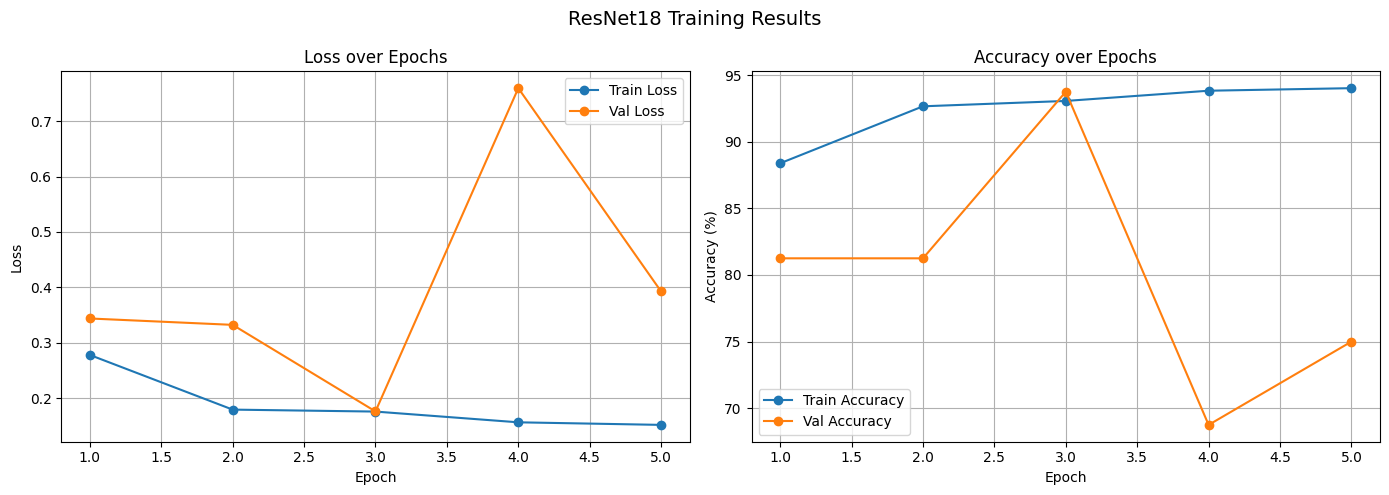

In [7]:
# ================================================
# Plot Training Curves
# ================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker="o")
ax1.plot(range(1, NUM_EPOCHS+1), val_losses,   label="Val Loss",   marker="o")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, label="Train Accuracy", marker="o")
ax2.plot(range(1, NUM_EPOCHS+1), val_accs,   label="Val Accuracy",   marker="o")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("ResNet18 Training Results", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# ================================================
# Final Evaluation on Test Set
# ================================================

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.63      0.76       234
   PNEUMONIA       0.82      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.85       624



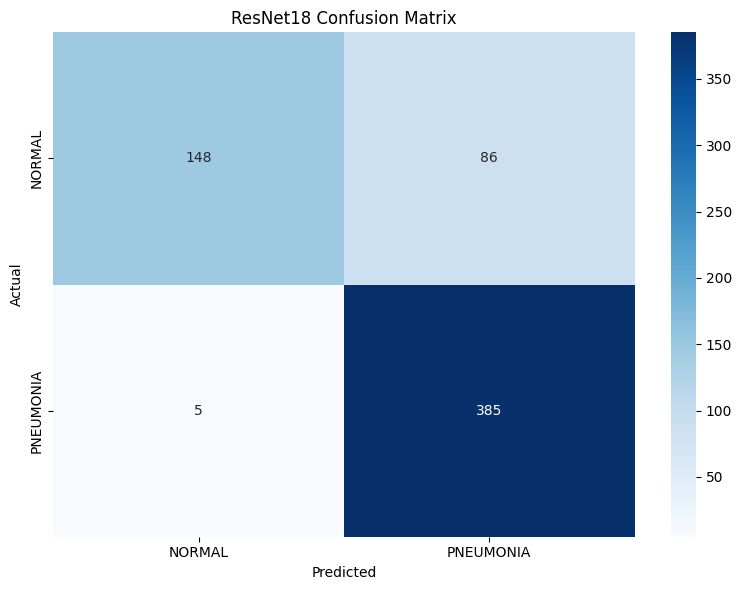

In [9]:
# ================================================
# Confusion Matrix
# ================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("ResNet18 Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [10]:
# ================================================
# Save Model
# ================================================

import os
os.makedirs("../outputs", exist_ok=True)

torch.save(model.state_dict(), "../outputs/resnet18_model.pth")
print("Model saved to outputs/resnet18_model.pth")

Model saved to outputs/resnet18_model.pth
